# Интеллектуальный анализ данных – весна 2025

# Домашнее задание 7: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов.


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

<!-- ![](meme.jpg) -->
<img src="meme.jpg" alt="Drawing" style="width: 700px;"/>

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [2]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
counts = np.array([8, 2])
probabilities = counts / counts.sum()
entropy = -np.sum(probabilities * np.log(probabilities))
entropy_rounded = np.round(entropy, 2)
print(entropy_rounded)

0.5


**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [3]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
def gini_index(class_counts):
    total = sum(class_counts)
    if total == 0:
        return 0
    proportions = [count / total for count in class_counts]
    return sum(p * (1 - p) for p in proportions)

def information_gain(parent_counts, left_counts, right_counts):
    H_parent = gini_index(parent_counts)
    H_left = gini_index(left_counts)
    H_right = gini_index(right_counts)
    total = sum(parent_counts)
    left_size = sum(left_counts)
    right_size = sum(right_counts)
    Q = H_parent - (left_size / total) * H_left - (right_size / total) * H_right
    return Q
parent_counts = [8, 2]
left_counts = [8, 0]
right_counts = [0, 2]
Q = information_gain(parent_counts, left_counts, right_counts)
Q_rounded = round(Q, 2)
print(f"Критерий информативности Q = {Q_rounded}")

Критерий информативности Q = 0.32


**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [4]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
target_values = np.array([1, 10, 5, 18, 100, 30, 50, 61, 84, 47])
prediction = np.mean(target_values)
print(f"Предсказание модели для всех объектов в листе: {prediction}")

Предсказание модели для всех объектов в листе: 40.6


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [5]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [6]:
def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame], 
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`
    
    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————-

    feature_vector = np.asarray(feature_vector).flatten()
    target_vector = np.asarray(target_vector).flatten()
    if len(np.unique(feature_vector)) == 1:
        return np.array([]), np.array([]), None, -np.inf
    
    if feature_type == "real":
        sorted_idx = np.argsort(feature_vector)
        sorted_features = feature_vector[sorted_idx]
        sorted_targets = target_vector[sorted_idx]
        unique_vals, first_occur = np.unique(sorted_features, return_index=True)
        thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2
        split_positions = first_occur[1:] - 1
        left_counts = split_positions + 1
        right_counts = len(feature_vector) - left_counts
        
        if task == "classification":
            cumsum = np.cumsum(sorted_targets)[split_positions]
            left_probs = cumsum / left_counts
            right_probs = (np.sum(sorted_targets) - cumsum) / right_counts
            
            left_gini = left_probs * (1 - left_probs)
            right_gini = right_probs * (1 - right_probs)
            ginis = (left_counts * left_gini + right_counts * right_gini) / len(feature_vector)
            ginis = 1 - ginis
        else:
            cumsum = np.cumsum(sorted_targets)[split_positions]
            cumsum_sq = np.cumsum(sorted_targets**2)[split_positions]
            
            left_var = cumsum_sq/left_counts - (cumsum/left_counts)**2
            right_var = (np.sum(sorted_targets**2)-cumsum_sq)/right_counts - \
                       ((np.sum(sorted_targets)-cumsum)/right_counts)**2
            
            ginis = np.var(target_vector) - (left_counts*left_var + right_counts*right_var)/len(feature_vector)
    
    else:
        unique_vals = np.unique(feature_vector)
        thresholds = unique_vals
        masks = feature_vector[:, None] == unique_vals[None, :]
        left_counts = masks.sum(axis=0)
        right_counts = len(feature_vector) - left_counts
        
        if task == "classification":
            left_sums = (target_vector[:, None] * masks).sum(axis=0)
            left_probs = left_sums / left_counts
            right_probs = (np.sum(target_vector) - left_sums) / right_counts
            
            left_gini = left_probs * (1 - left_probs)
            right_gini = right_probs * (1 - right_probs)
            ginis = 1 - (left_counts*left_gini + right_counts*right_gini)/len(feature_vector)
        else:
            left_sums = (target_vector[:, None] * masks).sum(axis=0)
            left_sums_sq = (target_vector[:, None]**2 * masks).sum(axis=0)
            
            left_var = left_sums_sq/left_counts - (left_sums/left_counts)**2
            right_var = (np.sum(target_vector**2)-left_sums_sq)/right_counts - \
                       ((np.sum(target_vector)-left_sums)/right_counts)**2
            
            ginis = np.var(target_vector) - (left_counts*left_var + right_counts*right_var)/len(feature_vector)
    if len(ginis) == 0 or np.all(np.isnan(ginis)):
        return np.array([]), np.array([]), None, -np.inf
    
    valid_mask = ~np.isnan(ginis)
    if not np.any(valid_mask):
        return np.array([]), np.array([]), None, -np.inf
    
    valid_ginis = np.where(valid_mask, ginis, -np.inf)
    best_idx = np.argmax(valid_ginis)
    
    return thresholds, ginis, thresholds[best_idx], ginis[best_idx]

Эту функцию можно протестировать на датасете `California`.

In [7]:
from sklearn.datasets import fetch_california_housing

In [8]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

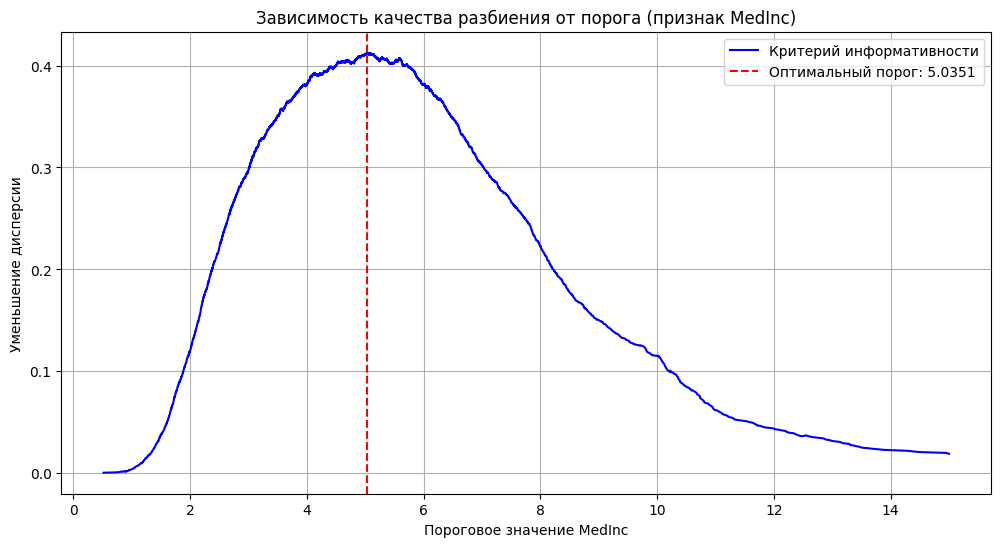


Результаты анализа:
Оптимальный порог: 5.0351
Максимальное уменьшение дисперсии: 0.4128
Количество рассмотренных порогов: 12927


In [10]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
feature = X['MedInc'].values
target = y
thresholds, ginis, best_threshold, best_gini = find_best_split(
    feature_vector=feature,
    target_vector=target,
    task="regression",
    feature_type="real"
)

plt.figure(figsize=(12, 6))
plt.plot(thresholds, ginis, 'b-', label='Критерий информативности')
plt.axvline(x=best_threshold, color='r', linestyle='--', 
            label=f'Оптимальный порог: {best_threshold:.4f}')
plt.xlabel('Пороговое значение MedInc')
plt.ylabel('Уменьшение дисперсии')
plt.title('Зависимость качества разбиения от порога (признак MedInc)')
plt.legend()
plt.grid(True)
plt.show()

print("\nРезультаты анализа:")
print(f"Оптимальный порог: {best_threshold:.4f}")
print(f"Максимальное уменьшение дисперсии: {best_gini:.4f}")
print(f"Количество рассмотренных порогов: {len(thresholds)}")

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

Лучшие предикаты для первой вершины:
1. MedInc:
   Порог: 5.0351
   Уменьшение дисперсии: 0.4128

2. AveRooms:
   Порог: 6.3743
   Уменьшение дисперсии: 0.1592

3. Latitude:
   Порог: 37.9300
   Уменьшение дисперсии: 0.0916

4. AveOccup:
   Порог: 3.1125
   Уменьшение дисперсии: 0.0739

5. Longitude:
   Порог: -121.8600
   Уменьшение дисперсии: 0.0504

6. HouseAge:
   Порог: 52.0000
   Уменьшение дисперсии: 0.0332

7. AveBedrms:
   Порог: 1.1034
   Уменьшение дисперсии: 0.0153

8. Population:
   Порог: 1163.0000
   Уменьшение дисперсии: 0.0028



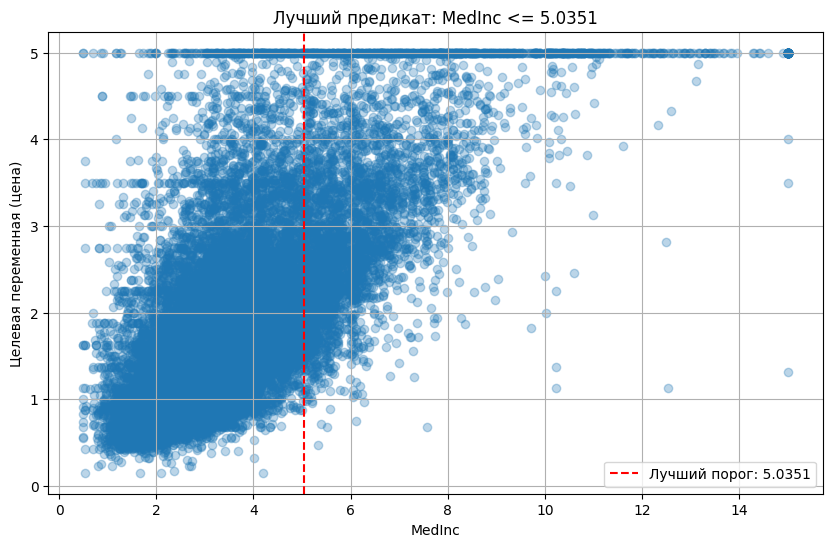

In [12]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
def find_best_split_reg(feature, target):
    sorted_idx = np.argsort(feature)
    sorted_feature = feature[sorted_idx]
    sorted_target = target[sorted_idx]
    thresholds = (sorted_feature[1:] + sorted_feature[:-1]) / 2
    cumsum = np.cumsum(sorted_target[:-1])
    cumsum_sq = np.cumsum(sorted_target[:-1]**2)
    n_left = np.arange(1, len(sorted_target))
    n_right = len(sorted_target) - n_left
    
    left_var = cumsum_sq/n_left - (cumsum/n_left)**2
    right_var = (np.sum(sorted_target**2)-cumsum_sq)/n_right - \
               ((np.sum(sorted_target)-cumsum)/n_right)**2
    
    gain = np.var(target) - (n_left*left_var + n_right*right_var)/len(target)
    
    valid_mask = ~np.isnan(gain)
    if not np.any(valid_mask):
        return None, -np.inf
    
    best_idx = np.nanargmax(gain)
    return thresholds[best_idx], gain[best_idx]
results = {}
for feature_name in X.columns:
    threshold, gain = find_best_split_reg(X[feature_name].values, y)
    results[feature_name] = {
        'threshold': threshold,
        'variance_reduction': gain
    }

sorted_results = sorted(results.items(), key=lambda x: -x[1]['variance_reduction'])
print("Лучшие предикаты для первой вершины:")
for i, (feature, stats) in enumerate(sorted_results, 1):
    print(f"{i}. {feature}:")
    print(f"   Порог: {stats['threshold']:.4f}")
    print(f"   Уменьшение дисперсии: {stats['variance_reduction']:.4f}\n")
best_feature, best_stats = sorted_results[0]
plt.figure(figsize=(10, 6))
plt.scatter(X[best_feature], y, alpha=0.3)
plt.axvline(x=best_stats['threshold'], color='r', linestyle='--',
            label=f'Лучший порог: {best_stats["threshold"]:.4f}')
plt.xlabel(best_feature)
plt.ylabel('Целевая переменная (цена)')
plt.title(f'Лучший предикат: {best_feature} <= {best_stats["threshold"]:.4f}')
plt.legend()
plt.grid(True)
plt.show()

**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [13]:
class DecisionTree:
    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification",
        max_surrogate_splits: int = 2
    ):
        if np.any([ftype not in ("real", "categorical") for ftype in feature_types]):
            raise ValueError("Unknown feature type detected.")
        self.feature_types = feature_types
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.task = task
        self.max_surrogate_splits = max_surrogate_splits
        self.tree = {}
        self.feature_score = Counter()

    def _split_node(self, X_subset: np.ndarray, y_subset: np.ndarray, node: dict, depth: int = 0):
        if (len(y_subset) == 0 or np.all(y_subset == y_subset[0]) or
           (self.max_depth is not None and depth >= self.max_depth)):
            node['node_type'] = 'leaf'
            node['label'] = Counter(y_subset).most_common(1)[0][0] if len(y_subset) > 0 else None
            return

        if self.task == 'regression':
            parent_impurity = ((y_subset - y_subset.mean()) ** 2).mean()
        else:
            classes, counts = np.unique(y_subset, return_counts=True)
            proportions = counts / counts.sum()
            parent_impurity = np.sum(proportions * (1 - proportions))

        best_split = {'feature': None, 'threshold': None, 'impurity': np.inf, 'mask': None}
        num_features = X_subset.shape[1]
        for col_idx in range(num_features):
            column = X_subset[:, col_idx]
            ftype = self.feature_types[col_idx]
            thresholds, gini_scores, threshold, impurity = find_best_split(column, y_subset, self.task, ftype)
            if threshold is None:
                continue

            if impurity < best_split['impurity']:
                mask_nonmissing = ~pd.isna(column)
                if ftype == 'real':
                    split_mask = (column <= threshold) & mask_nonmissing
                    fallback_side = split_mask.sum() >= mask_nonmissing.sum() - split_mask.sum()
                    split_mask[~mask_nonmissing] = fallback_side
                else:
                    split_mask = (column == threshold) & mask_nonmissing
                    fallback_side = split_mask.sum() >= mask_nonmissing.sum() - split_mask.sum()
                    split_mask[~mask_nonmissing] = fallback_side

                best_split.update({
                    'feature': col_idx,
                    'threshold': threshold,
                    'impurity': impurity,
                    'mask': split_mask
                })

        if best_split['feature'] is None:
            node['node_type'] = 'leaf'
            node['label'] = Counter(y_subset).most_common(1)[0][0]
            return

        node['node_type'] = 'internal'
        node['split_feature'] = best_split['feature']
        feature_type = self.feature_types[best_split['feature']]
        if feature_type == 'real':
            node['split_threshold'] = best_split['threshold']
        else:
            node['split_category'] = best_split['threshold']

        left_count = best_split['mask'].sum()
        right_count = len(y_subset) - left_count
        node['left_size'] = int(left_count)
        node['right_size'] = int(right_count)

        info_gain = parent_impurity - best_split['impurity']
        self.feature_score[best_split['feature']] += info_gain * len(y_subset)

        surrogate_splits = []
        primary_mask = best_split['mask']
        primary_nonmissing = ~pd.isna(X_subset[:, best_split['feature']])
        for alt_feat_idx in range(num_features):
            if alt_feat_idx == best_split['feature']:
                continue
            alt_col = X_subset[:, alt_feat_idx]
            valid_entries = primary_nonmissing & (~pd.isna(alt_col))
            if valid_entries.sum() == 0:
                continue

            alt_ftype = self.feature_types[alt_feat_idx]
            _, _, alt_threshold, _ = find_best_split(alt_col, y_subset, self.task, alt_ftype)
            if alt_threshold is None:
                continue

            if alt_ftype == 'real':
                alt_mask = alt_col <= alt_threshold
            else:
                alt_mask = alt_col == alt_threshold

            agreement = np.mean(primary_mask[valid_entries] == alt_mask[valid_entries])
            surrogate_splits.append((agreement, alt_feat_idx, alt_threshold))

        surrogate_splits.sort(key=lambda x: x[0], reverse=True)
        node['surrogate_rules'] = [{'feature': idx, 'threshold': thr} for _, idx, thr in surrogate_splits[:self.max_surrogate_splits]]

        node['left'], node['right'] = {}, {}
        self._split_node(X_subset[best_split['mask']], y_subset[best_split['mask']], node['left'], depth + 1)
        self._split_node(X_subset[~best_split['mask']], y_subset[~best_split['mask']], node['right'], depth + 1)

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self._split_node(X, y, self.tree)

    def _traverse_tree(self, x_row: np.ndarray, node: dict):
        if node['node_type'] == 'leaf':
            return node['label']

        feat_idx = node['split_feature']
        ftype = self.feature_types[feat_idx]
        value = x_row[feat_idx]
        go_left = None

        if ftype == 'real' and not np.isnan(value):
            go_left = value <= node['split_threshold']
        elif ftype == 'categorical' and not pd.isna(value):
            go_left = value == node['split_category']

        if go_left is None:
            for surrogate in node.get('surrogate_rules', []):
                surrogate_value = x_row[surrogate['feature']]
                if pd.isna(surrogate_value) or (isinstance(surrogate_value, float) and np.isnan(surrogate_value)):
                    continue
                surrogate_ftype = self.feature_types[surrogate['feature']]
                if surrogate_ftype == 'real':
                    go_left = surrogate_value <= surrogate['threshold']
                else:
                    go_left = surrogate_value == surrogate['threshold']
                break

        if go_left is None:
            go_left = node['left_size'] >= node['right_size']

        next_node = 'left' if go_left else 'right'
        return self._traverse_tree(x_row, node[next_node])

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.array([self._traverse_tree(x, self.tree) for x in X])

    def compute_feature_importances(self) -> np.ndarray:
        total_gain = sum(self.feature_score.values())
        importances = np.zeros(len(self.feature_types))
        if total_gain > 0:
            for f_idx, gain in self.feature_score.items():
                importances[f_idx] = gain / total_gain
        return importances


При поиске лучшего разбиения создается маска, которая отмечает все непропущенные значения в текущем столбце. Если невозможно использовать основной признак из-за пропуска, дерево использует surrogate splits.
agreement = np.mean(primary_mask[valid_entries] == alt_mask[valid_entries]):
Он вычисляет, насколько хорошо альтернативный признак "имитирует" поведение главного:
primary_mask — это результат разбиения по главному признаку.
alt_mask — результат разбиения по альтернативному признаку.
Если они совпадают часто, то такой признак считается хорошим кандидатом на роль суррогата.

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

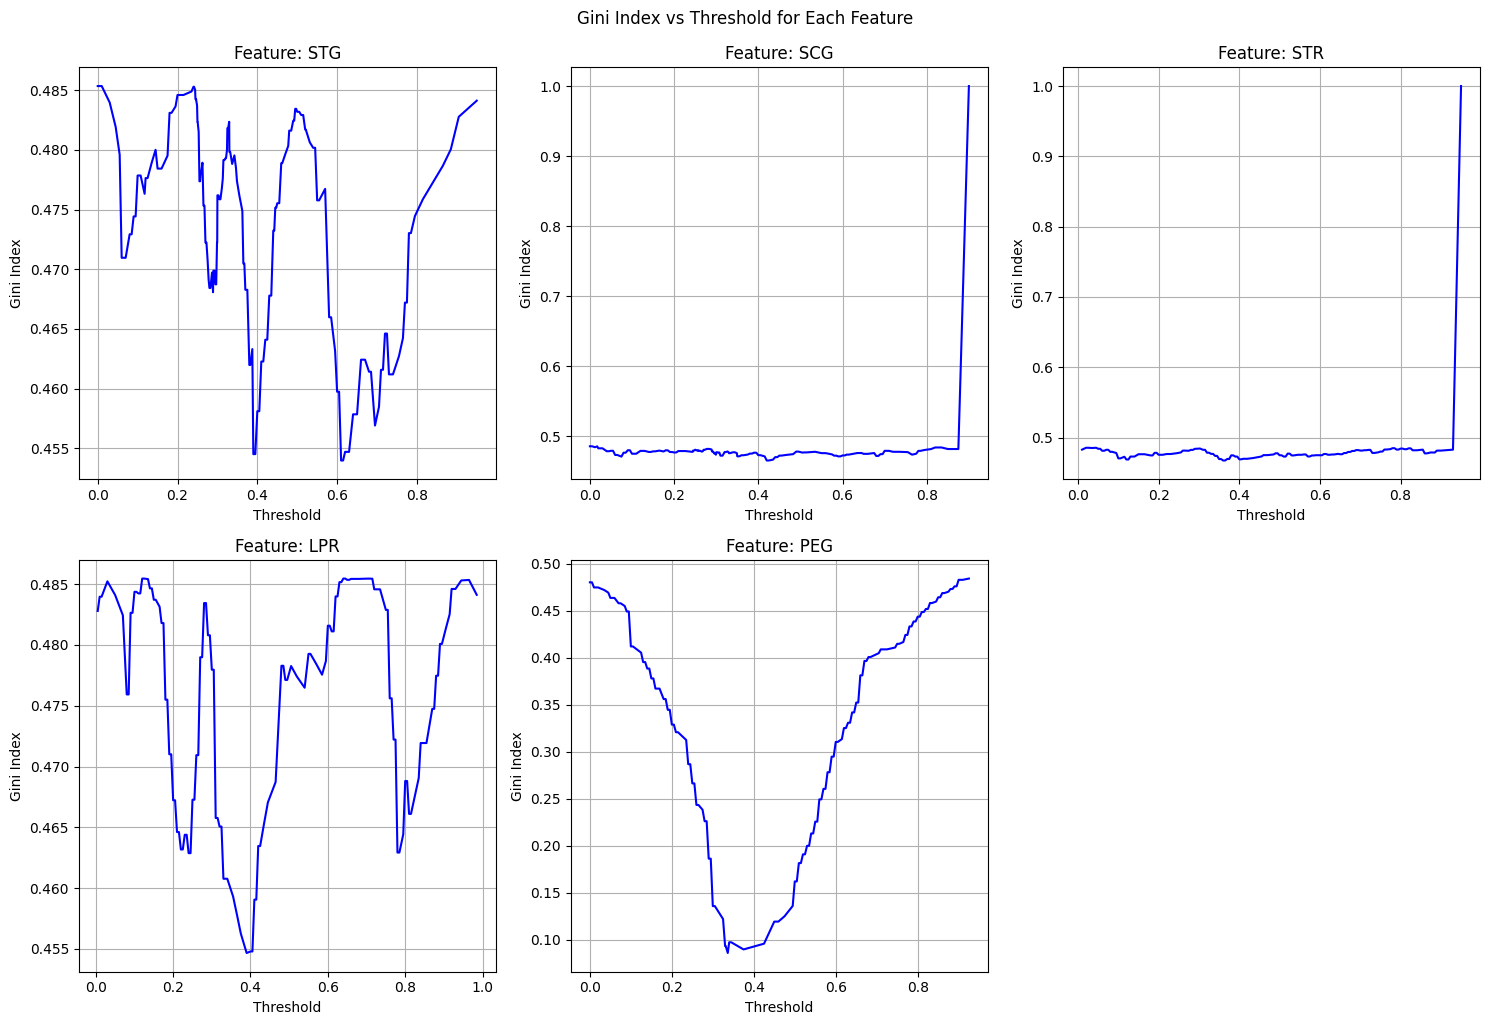

In [14]:
def calculate_gini(y, mask):
    if len(y) == 0:
        return 0
    
    n_left = np.sum(mask)
    n_right = len(y) - n_left
    
    if n_left == 0 or n_right == 0:
        return 1.0
    
    left_counts = np.bincount(y[mask])
    right_counts = np.bincount(y[~mask])
    
    p_left = left_counts / n_left
    p_right = right_counts / n_right
    
    gini_left = 1 - np.sum(p_left ** 2)
    gini_right = 1 - np.sum(p_right ** 2)
    
    gini = (n_left * gini_left + n_right * gini_right) / len(y)
    return gini

data = pd.read_csv('students.csv', index_col=0)
X = data.iloc[:, :5].values
y = data.iloc[:, 5].values
feature_names = data.columns[:5].tolist()

plt.figure(figsize=(15, 10))

for i in range(5):
    feature = X[:, i]
    sorted_feature = np.sort(feature)
    thresholds = (sorted_feature[:-1] + sorted_feature[1:]) / 2
    gini_values = []
    
    for thr in thresholds:
        mask = feature <= thr
        gini = calculate_gini(y, mask)
        gini_values.append(gini)
    plt.subplot(2, 3, i+1)
    plt.plot(thresholds, gini_values, 'b-')
    plt.xlabel('Threshold')
    plt.ylabel('Gini Index')
    plt.title(f'Feature: {feature_names[i]}')
    plt.grid(True)

plt.tight_layout()
plt.suptitle('Gini Index vs Threshold for Each Feature', y=1.02)
plt.show()


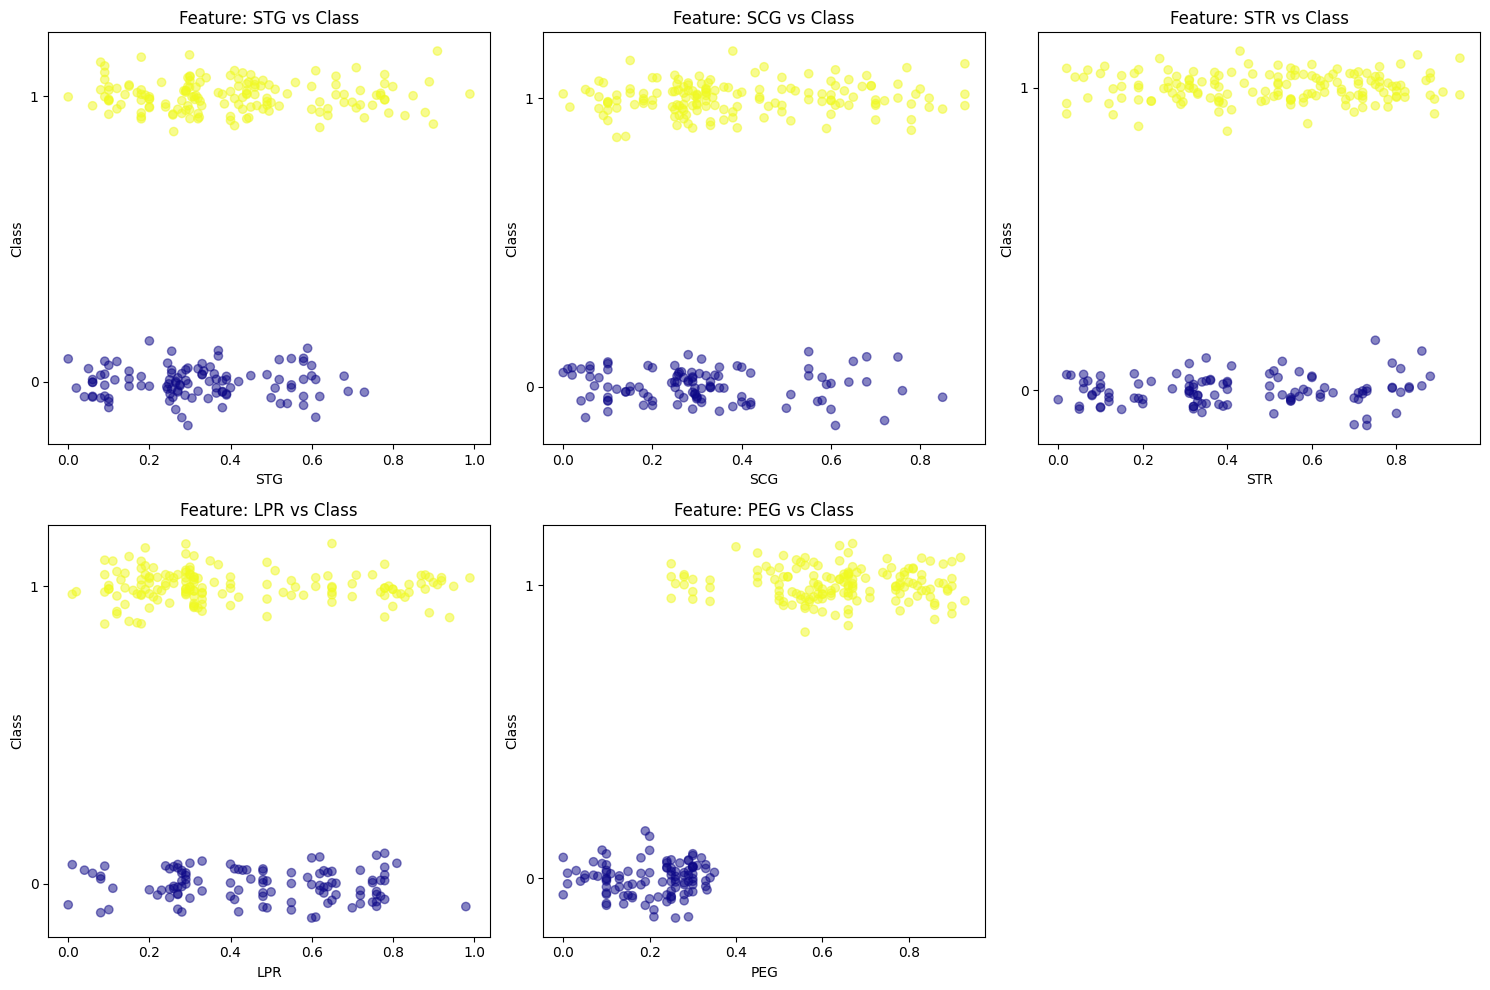

In [17]:
plt.figure(figsize=(15, 10))

for i in range(5):
    plt.subplot(2, 3, i+1)
    jitter = 0.05 * np.random.randn(len(y))
    plt.scatter(X[:, i], y + jitter, alpha=0.5, c=y, cmap='plasma')
    plt.xlabel(feature_names[i])
    plt.ylabel('Class')
    plt.yticks([0, 1])
    plt.title(f'Feature: {feature_names[i]} vs Class')

plt.tight_layout()
plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?


Почти идеально выборка делится по PEG. У нее единственный минимум в значении около 0.08 при пороге около 0.38, что наблюдается и на диаграмме рассеяния
(два класса разных цветов почти полностью разместились по две стороны от этой границы).
У хороших признакей кривая Джини имеет чётко выраженный минимум , что указывает на наличие оптимального порога, 
дающего почти идеальное разделение классов.
Для STR и SCG, коэф. Джини всегда для них равен 0.4, кроме случая, пока порог не достигнет критического значения, после чего происходит резкое увеличение.
На диаграмме рассеяния невозможно провесит границу для разделения признаков, потому что они почти полностью покрывают друг друга.

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). 

1. Скачайте таблицу `agaricus-lepiota.data` (из [Data Folder](https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/)), 
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа. 

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

def load_and_preprocess_data():
    cols = [
        'target', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 
        'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 
        'gill-color', 'stalk-shape', 'stalk-root', 
        'stalk-surface-above-ring', 'stalk-surface-below-ring', 
        'stalk-color-above-ring', 'stalk-color-below-ring', 
        'veil-type', 'veil-color', 'ring-number', 'ring-type',
        'spore-print-color', 'population', 'habitat'
    ]
    
    data = pd.read_csv('agaricus-lepiota.data', header=None, names=cols)
    encoders = {col: LabelEncoder() for col in cols}
    
    encoded_data = data.copy()
    for col in cols:
        if '?' in data[col].unique():
            encoded_data[col] = data[col].replace('?', 'unknown')
        encoded_data[col] = encoders[col].fit_transform(encoded_data[col])
    
    return encoded_data, encoders
def train_and_evaluate(data):
    X = data.drop('target', axis=1)
    y = data['target']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.5, random_state=42, stratify=y
    )
    model = DecisionTreeClassifier(
        max_depth=5, 
        min_samples_split=10,
        criterion='gini',
        random_state=42
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    importances = model.feature_importances_
    features = sorted(
        zip(X.columns, importances),
        key=lambda x: x[1], 
        reverse=True
    )
    
    return acc, features

def main():
    data, encoders = load_and_preprocess_data()
    accuracy, important_features = train_and_evaluate(data)
    print(f"Model Accuracy: {accuracy:.4f}")
    print("\nFeature Importances:")
    for feature, importance in important_features:
        if importance > 0.001:
            print(f"{feature}: {importance:.4f}")

if __name__ == "__main__":
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.metrics import accuracy_score
    
    main()

Model Accuracy: 0.9813

Feature Importances:
gill-color: 0.3624
spore-print-color: 0.1841
population: 0.1806
gill-size: 0.1177
stalk-root: 0.0396
odor: 0.0389
stalk-shape: 0.0297
habitat: 0.0196
stalk-color-above-ring: 0.0170
cap-color: 0.0057
stalk-surface-below-ring: 0.0047


## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [20]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [21]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

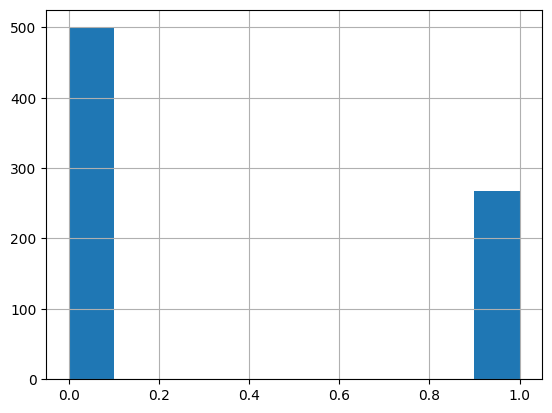

In [22]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [25]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=65, stratify=y)

X_train_train, X_train_val, y_train_train, y_train_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42, stratify=y_train)

print("\nРазмеры выборок:")
print(f"Обучающая-обучающая: {X_train_train.shape[0]} samples ({X_train_train.shape[0]/len(data):.2%} от исходного)")
print(f"Обучающая-валидационная: {X_train_val.shape[0]} samples ({X_train_val.shape[0]/len(data):.2%} от исходного)")
print(f"Тестовая: {X_test.shape[0]} samples ({X_test.shape[0]/len(data):.2%} от исходного)")

print("\nРаспределение классов:")
print("Обучающая-обучающая:\n", y_train_train.value_counts(normalize=True))
print("Обучающая-валидационная:\n", y_train_val.value_counts(normalize=True))
print("Тестовая:\n", y_test.value_counts(normalize=True))


Размеры выборок:
Обучающая-обучающая: 375 samples (48.83% от исходного)
Обучающая-валидационная: 162 samples (21.09% от исходного)
Тестовая: 231 samples (30.08% от исходного)

Распределение классов:
Обучающая-обучающая:
 Outcome
0    0.650667
1    0.349333
Name: proportion, dtype: float64
Обучающая-валидационная:
 Outcome
0    0.654321
1    0.345679
Name: proportion, dtype: float64
Тестовая:
 Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке. 


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [26]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
max_depth_values = [3, 5, 7, 10, 15, 20, None]
min_samples_leaf_values = [1, 3, 5, 7, 10, 15, 20]

best_f1 = 0
best_params = {}

for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        model.fit(X_train_train, y_train_train)
        y_pred = model.predict(X_train_val)
        f1 = f1_score(y_train_val, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_params = {
                'max_depth': max_depth,
                'min_samples_leaf': min_samples_leaf
            }

print(f"Лучшие параметры: {best_params}")
print(f"Лучшая F1-мера на валидационной выборке: {best_f1:.4f}")
final_model = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC-ROC': roc_auc_score(y_test, y_proba)
}

print("\nМетрики на тестовой выборке:")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 15}
Лучшая F1-мера на валидационной выборке: 0.6891

Метрики на тестовой выборке:
Accuracy: 0.7619
Precision: 0.6806
Recall: 0.6049
F1-score: 0.6405
AUC-ROC: 0.7900


**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [27]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
from sklearn.ensemble import BaggingClassifier

base_tree = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=65
)

bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    random_state=65
)

bagging_model.fit(X_train, y_train)

y_pred_bag = bagging_model.predict(X_test)
y_proba_bag = bagging_model.predict_proba(X_test)[:, 1]

metrics_bag = {
    'Accuracy': accuracy_score(y_test, y_pred_bag),
    'Precision': precision_score(y_test, y_pred_bag),
    'Recall': recall_score(y_test, y_pred_bag),
    'F1-score': f1_score(y_test, y_pred_bag),
    'AUC-ROC': roc_auc_score(y_test, y_proba_bag)
}

print("\nМетрики BaggingClassifier на тестовой выборке:")
for name, value in metrics_bag.items():
    print(f"{name}: {value:.4f}")

# Сравнение с одиночным деревом
print("\nСравнение с одиночным деревом:")
print("{:<10} {:<10} {:<10}".format('Метрика', 'Дерево', 'Бэггинг'))
for name in metrics.keys():
    print("{:<10} {:<10.4f} {:<10.4f}".format(name, metrics[name], metrics_bag[name]))


Метрики BaggingClassifier на тестовой выборке:
Accuracy: 0.7706
Precision: 0.7121
Recall: 0.5802
F1-score: 0.6395
AUC-ROC: 0.8386

Сравнение с одиночным деревом:
Метрика    Дерево     Бэггинг   
Accuracy   0.7619     0.7706    
Precision  0.6806     0.7121    
Recall     0.6049     0.5802    
F1-score   0.6405     0.6395    
AUC-ROC    0.7900     0.8386    


**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации. 
3. Выберите ту пару значений, которая даёт наилучшее среднее качество. 

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [29]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 15, 20]
}

rf = RandomForestClassifier(n_estimators=50, random_state=65)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_rf_params = grid_search.best_params_
print(f"Лучшие параметры Random Forest: {best_rf_params}")
print(f"Лучшая F1-мера при кросс-валидации: {grid_search.best_score_:.4f}")

final_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=best_rf_params['max_depth'],
    min_samples_split=best_rf_params['min_samples_split'],
    random_state=42
)
final_rf.fit(X_train, y_train)

y_pred_rf = final_rf.predict(X_test)
y_proba_rf = final_rf.predict_proba(X_test)[:, 1]

metrics_rf = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-score': f1_score(y_test, y_pred_rf),
    'AUC-ROC': roc_auc_score(y_test, y_proba_rf)
}

print("\nМетрики Random Forest на тестовой выборке:")
for name, value in metrics_rf.items():
    print(f"{name}: {value:.4f}")

print("\nСравнение всех моделей:")
print("{:<15} {:<8} {:<8} {:<8}".format('Метрика', 'Дерево', 'Бэггинг', 'RF'))
for name in metrics_rf.keys():
    print("{:<15} {:<8.4f} {:<8.4f} {:<8.4f}".format(
        name,
        metrics[name],
        metrics_bag[name],
        metrics_rf[name]
    ))

best_model = np.argmax([
    metrics['F1-score'],
    metrics_bag['F1-score'],
    metrics_rf['F1-score']
])
model_names = ['Decision Tree', 'Bagging', 'Random Forest']
print(f"\nЛучшая модель по F1-score: {model_names[best_model]}")

Лучшие параметры Random Forest: {'max_depth': 7, 'min_samples_split': 5}
Лучшая F1-мера при кросс-валидации: 0.6341

Метрики Random Forest на тестовой выборке:
Accuracy: 0.7619
Precision: 0.6806
Recall: 0.6049
F1-score: 0.6405
AUC-ROC: 0.8355

Сравнение всех моделей:
Метрика         Дерево   Бэггинг  RF      
Accuracy        0.7619   0.7706   0.7619  
Precision       0.6806   0.7121   0.6806  
Recall          0.6049   0.5802   0.6049  
F1-score        0.6405   0.6395   0.6405  
AUC-ROC         0.7900   0.8386   0.8355  

Лучшая модель по F1-score: Decision Tree


**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

n_estimators=1: AUC-ROC=0.6935
n_estimators=5: AUC-ROC=0.7797
n_estimators=10: AUC-ROC=0.8126
n_estimators=20: AUC-ROC=0.8173
n_estimators=30: AUC-ROC=0.8321
n_estimators=40: AUC-ROC=0.8336
n_estimators=50: AUC-ROC=0.8319
n_estimators=75: AUC-ROC=0.8342
n_estimators=100: AUC-ROC=0.8361
n_estimators=150: AUC-ROC=0.8359
n_estimators=200: AUC-ROC=0.8356


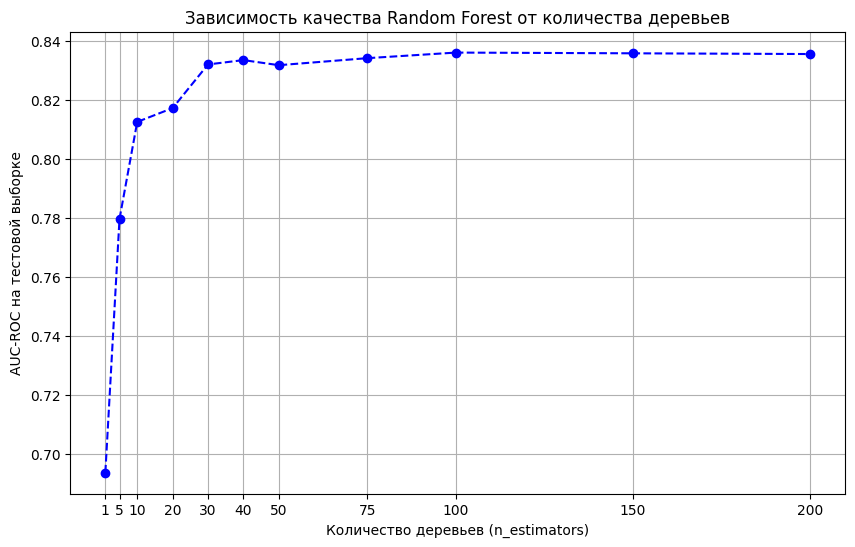

Прирост от 1 до 5 деревьев: 0.0861
Прирост от 5 до 10 деревьев: 0.0329
Прирост от 10 до 20 деревьев: 0.0047
Прирост от 20 до 30 деревьев: 0.0148
Прирост от 30 до 40 деревьев: 0.0015
Прирост от 40 до 50 деревьев: -0.0017
Прирост от 50 до 75 деревьев: 0.0024
Прирост от 75 до 100 деревьев: 0.0019
Прирост от 100 до 150 деревьев: -0.0002
Прирост от 150 до 200 деревьев: -0.0002


In [30]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
n_trees_range = [1, 5, 10, 20, 30, 40, 50, 75, 100, 120, , 150, 200]
auc_scores = []

best_max_depth = best_rf_params['max_depth']
best_min_samples_split = best_rf_params['min_samples_split']

for n_trees in n_trees_range:
    rf = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=best_max_depth,
        min_samples_split=best_min_samples_split,
        random_state=65
    )
    rf.fit(X_train, y_train)
    y_proba = rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    auc_scores.append(auc)
    print(f"n_estimators={n_trees}: AUC-ROC={auc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(n_trees_range, auc_scores, marker='o', linestyle='--', color='b')
plt.xlabel('Количество деревьев (n_estimators)')
plt.ylabel('AUC-ROC на тестовой выборке')
plt.title('Зависимость качества Random Forest от количества деревьев')
plt.grid(True)
plt.xticks(n_trees_range)
plt.show()

for i in range(1, len(auc_scores)):
    improvement = auc_scores[i] - auc_scores[i-1]
    print(f"Прирост от {n_trees_range[i-1]} до {n_trees_range[i]} деревьев: {improvement:.4f}")

Максимальное значение AUC-ROC достигается при 75 деревьях, 

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

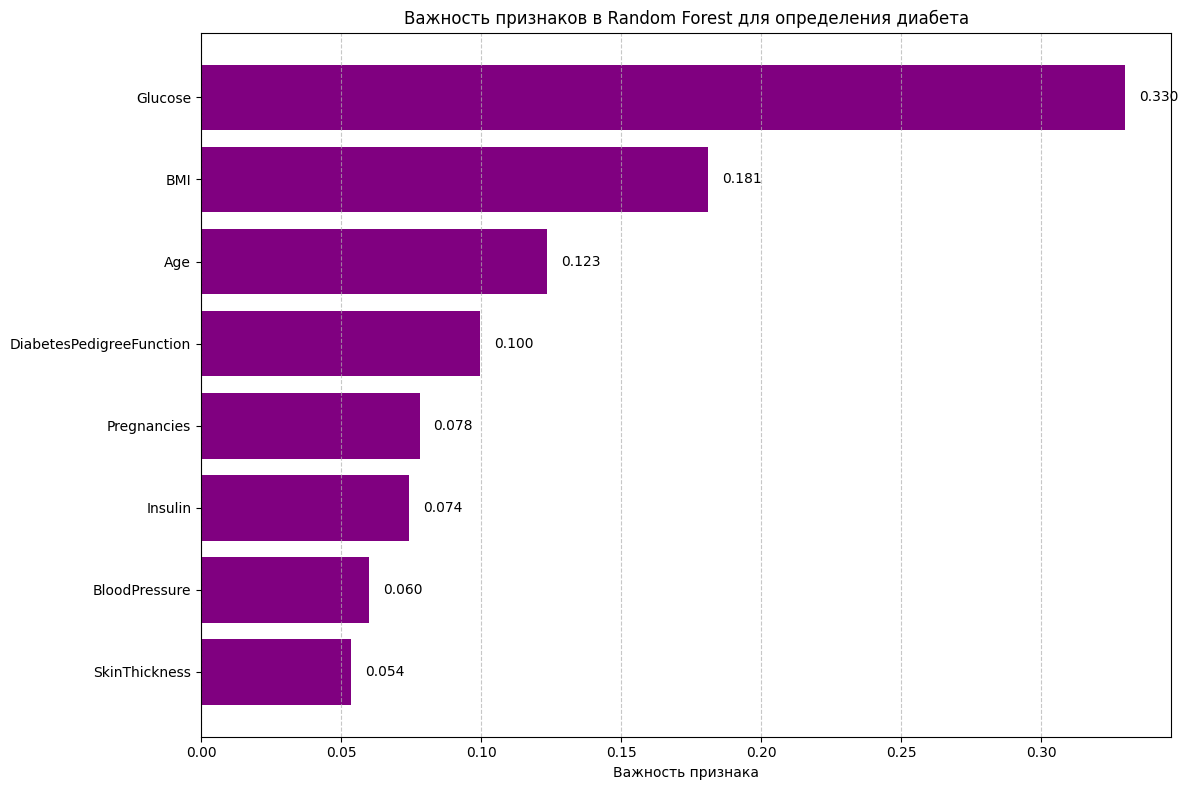


Самый важный признак: 'Glucose' с важностью 0.330


In [31]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
feature_importances = final_rf.feature_importances_
feature_names = X_train.columns

sorted_idx = np.argsort(feature_importances)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importances = feature_importances[sorted_idx]

plt.figure(figsize=(12, 8))
plt.barh(sorted_features, sorted_importances, color='purple')
plt.gca().invert_yaxis()
plt.xlabel('Важность признака')
plt.title('Важность признаков в Random Forest для определения диабета')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(sorted_importances):
    plt.text(v + 0.005, i, f"{v:.3f}", color='black', va='center')

plt.tight_layout()
plt.show()

most_important_feature = sorted_features[0]
most_important_value = sorted_importances[0]
print(f"\nСамый важный признак: '{most_important_feature}' с важностью {most_important_value:.3f}")